In [4]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [2]:
ENV_PATH = r"C:\Users\D\Python scripts\Innopolis 2026\AI architecht\.env"

# Загружаем данные

In [9]:
query = """
    SELECT
        f.rental_duration,
        f.rental_rate,
        f.replacement_cost,
        f.length AS film_length,
        p.amount
    FROM payment p
    JOIN rental r ON p.rental_id = r.rental_id
    JOIN inventory i ON r.inventory_id = i.inventory_id
    JOIN film f ON i.film_id = f.film_id
"""

load_dotenv(ENV_PATH )
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")

conn_url = f"postgresql://{user}:{password}@{host}:{port}/{database}"
engine = create_engine(conn_url)

df = pd.read_sql(query, engine)

In [10]:
df.head()

,rental_duration,rental_rate,replacement_cost,film_length,amount
0,6,4.99,19.99,153,7.99
1,5,0.99,15.99,130,1.99
2,3,4.99,9.99,138,7.99
3,5,2.99,11.99,100,2.99
4,6,4.99,16.99,165,7.99


Попытаемся предсказать сумму платежа за прокат на основе других переменных

amount - целевая переменная

# 1. Изучаем характеристики целевой переменной

In [12]:
df['amount'].describe().reset_index().T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
amount,14596.0,4.200606,2.368946,0.0,2.99,3.99,4.99,11.99


In [17]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

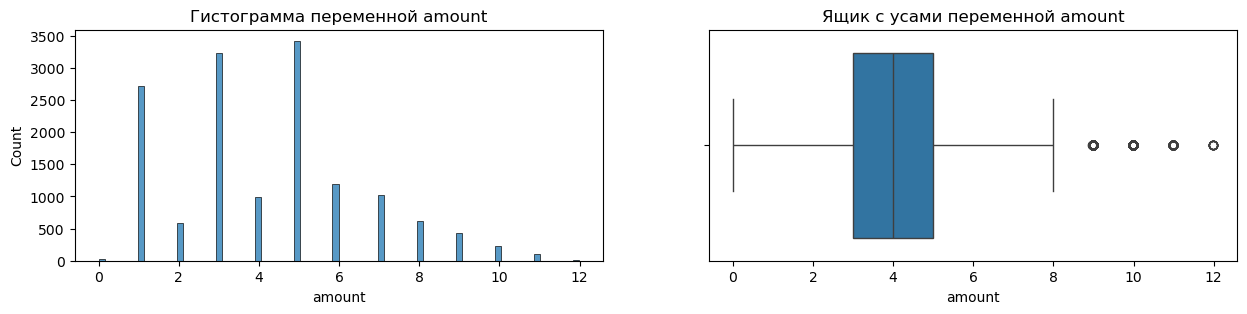

In [18]:
visualize_distribution(df, variable = "amount")

# 2. Чистим данные

In [46]:
# Убираем из целевой переменной нули
df = df[df["amount"] != 0]

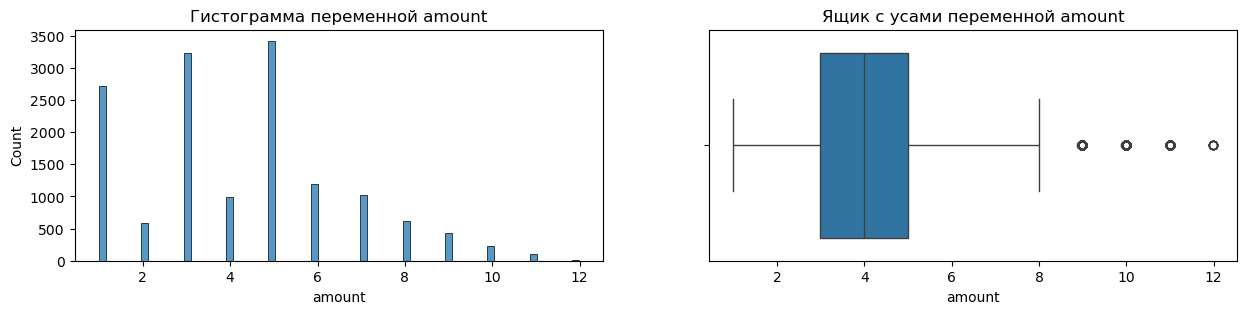

In [47]:
visualize_distribution(df, variable = "amount")

# 3. Обучим модели линейной регрессии

#### Простая модель $amount_i = w_0 + w_1 \cdot rental\_duration_i$

In [48]:
# Определяем целевую переменную и набор признаков
target_col = ["amount"]
features_col = ["rental_duration"]

In [49]:
# Делим выборку на обучающую и тестовую
X = df[features_col]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
# random_state нужен, чтобы впоследствии воспроизвести состав train и test выборок

In [55]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

In [50]:
# Инициализуем и обучаем модель линейной регрессии
lin_reg = LinearRegression()    # Инициализация
lin_reg.fit(X_train, y_train)   # Обучение модели

LinearRegression()

In [56]:
def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [51]:
# Делаем предсказания на тестовой выборке
y_pred = lin_reg.predict(X_test)

In [57]:
def get_predictions(model, X_test):
    return model.predict(X_test)

In [68]:
def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

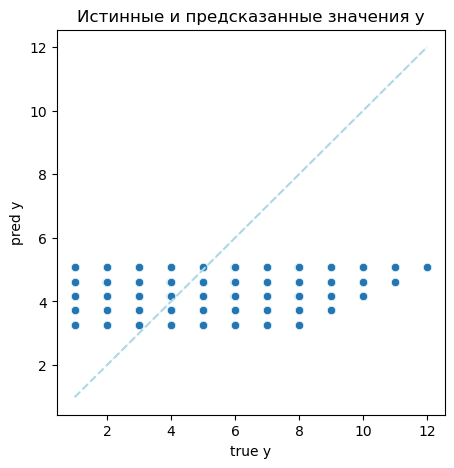

In [53]:
# Визуализуем предсказание на тестовой выборке
visualize_prediction(y_test, y_pred)

In [54]:
# Считаем метрики качества на тестовой выборке
show_metrics(y_test, y_pred)

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  5.236386896190262
RMSE:  2.2883152964987716
MAE:  1.8737749733872116
MAPE:  0.8508482015655517
R2:  0.08387681762941868


C:\Users\D\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:4026: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
C:\Users\D\AppData\Local\Temp\ipykernel_2040\615285900.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Среднеквадратическое отклонение Y: ', np.std(y_true)[0])


#### Модель $amount_i = w_0 + w_1 \cdot rental\_duration_i + w_2 \cdot rental\_rate_i$

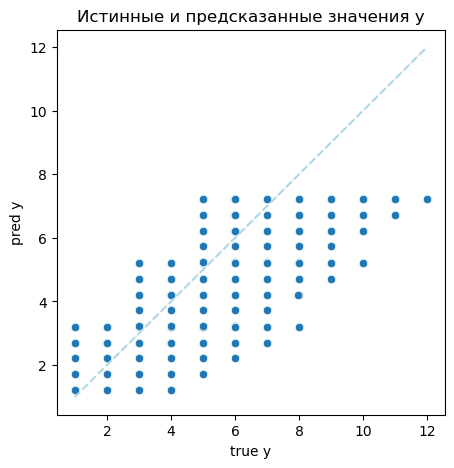

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  2.473467615578452
RMSE:  1.5727261731078466
MAE:  1.2671036345247122
MAPE:  0.42389295928559323
R2:  0.5672586712179468


In [69]:
target_col = ["amount"]
features_col = ["rental_duration", "rental_rate"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Модель $amount_i = w_0 + w_1 \cdot rental\_duration_i + w_2 \cdot rental\_rate_i + w_3 \cdot replacement\_cost_i + w_4 \cdot film\_length_i$

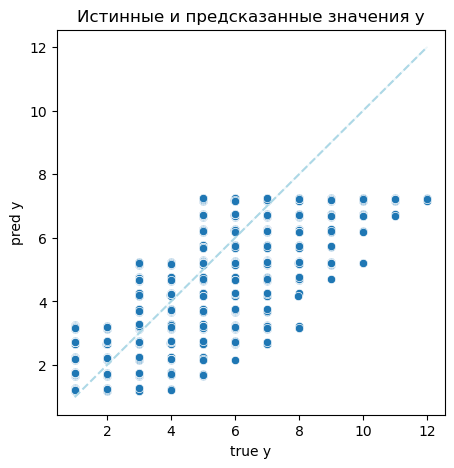

Среднее значение Y:  4.22537533790809
Среднеквадратическое отклонение Y:  2.3907762184928822
MSE:  2.4729656829094946
RMSE:  1.572566590930093
MAE:  1.2671665579464737
MAPE:  0.4244104785981251
R2:  0.5673464859961779


In [70]:
target_col = ["amount"]
features_col = ["rental_duration", "rental_rate", "replacement_cost", "film_length"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

# 4. Интерпретируем полученную модель

In [101]:
w0 = model.intercept_   # Забираем intercept
weights = model.coef_   # Забираем веса модели
features = model.feature_names_in_
pd.Series(dict(zip(features.tolist()+['intercept'], weights[0].tolist()+[w0[0]])))

rental_duration    -0.492447
rental_rate         1.003420
replacement_cost    0.004919
film_length        -0.000062
intercept           3.586846
dtype: float64

$\hat{amount} = 3.5868 - 0.4924 \cdot rental\_duration_i + 1.0034 \cdot rental\_rate_i + 0.0049 \cdot replacement\_cost_i - 0.00006 \cdot film\_length_i$

# 5. Повышаем качество модели

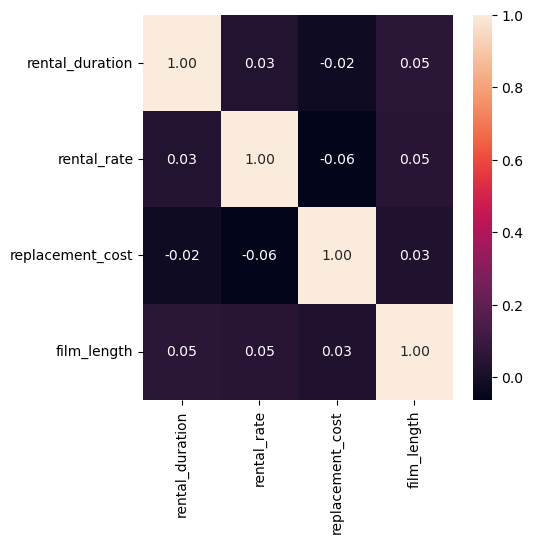

In [104]:
# Проверям переменные на мультиколлинеарность и убираем те, которые тесно скоррелированы
fig, ax = plt.subplots(1,1, figsize = (5,5))
sns.heatmap(df[features_col].corr(), annot = True, fmt='.2f')
plt.show()

Среди признаков нет тех, которые взаимно скоррелированы, следовательно, все они могут остаться в модели